# 03 Modelling Normal Cycling Counts

This notebook models the expected number of cyclists in each 2-hour interval using the pre-processed AWV data. The aim is to describe normal cycling behaviour across time, location, and direction, so that deviations from expected traffic levels can be identified later.

We start with a baseline Poisson count model and use diagnostics to assess its limitations, including overdispersion, residual patterns, zero counts, and possible non-linear effects. 

Alternative specifications are then evaluated, including models that allow for overdispersion, such as negative binomial. Interactions are considered when they are supported by diagnostics. A more flexible machine learning model is also fitted as a predictive benchmark. 

Model selection is guided by diagnostics, valid information criteria, and out-of-sample performance.


### Packages, path, data reading

In [1]:
#Packages
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance
from scipy import stats

import numpy as np
import pandas as pd

#Path
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"

#Data
counts_model_final = pd.read_csv(
    processed_folder / "counts_model_final.csv"
)

counts_model_final["date"] = pd.to_datetime(
    counts_model_final["date"],
    errors="coerce"
)

In [2]:
counts_model_final.info()

pd.set_option("display.max_columns", None)
counts_model_final.head()

<class 'pandas.DataFrame'>
RangeIndex: 4587736 entries, 0 to 4587735
Data columns (total 27 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   site_id                     int64         
 1   direction                   str           
 2   year                        int64         
 3   date                        datetime64[us]
 4   month                       int64         
 5   weekday                     str           
 6   hour_bin                    int64         
 7   count                       float64       
 8   observed_intervals          int64         
 9   total_intervals             int64         
 10  missing_intervals           int64         
 11  missing_share               float64       
 12  expected_intervals_for_row  int64         
 13  count_rescaled              int64         
 14  rescaled                    int64         
 15  longitude                   float64       
 16  latitude                    f

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


### Time-based model development split

Because the data are ordered in time, the modelling dataset is split chronologically. This avoids using future observations to predict earlier behaviour and gives a more realistic assessment of how well the models generalise to later periods.

The data are divided into three periods:

- **Training period:** May 2022 to April 2024  
  Used to fit the initial model specifications.

- **Validation period:** May 2024 to April 2025  
  Used to compare model specifications, assess diagnostics, and guide model selection.

- **Prediction period:** May 2025 to April 2026  
  Used to estimate expected cycling counts for the period in which deviations will be identified.


In [3]:

training_start = pd.to_datetime("2022-05-01")
training_end = pd.to_datetime("2024-04-30")

validation_start = pd.to_datetime("2024-05-01")
validation_end = pd.to_datetime("2025-04-30")

prediction_start = pd.to_datetime("2025-05-01")
prediction_end = pd.to_datetime("2026-04-30")


train_data = counts_model_final[
    (counts_model_final["date"] >= training_start) &
    (counts_model_final["date"] <= training_end)
].copy()

validation_data = counts_model_final[
    (counts_model_final["date"] >= validation_start) &
    (counts_model_final["date"] <= validation_end)
].copy()

prediction_data = counts_model_final[
    (counts_model_final["date"] >= prediction_start) &
    (counts_model_final["date"] <= prediction_end)
].copy()


split_summary = pd.DataFrame({
    "period": ["Training", "Validation", "Prediction"],
    "start_date": [
        train_data["date"].min(),
        validation_data["date"].min(),
        prediction_data["date"].min(),
    ],
    "end_date": [
        train_data["date"].max(),
        validation_data["date"].max(),
        prediction_data["date"].max(),
    ],
    "observations": [
        train_data.shape[0],
        validation_data.shape[0],
        prediction_data.shape[0],
    ],
    "unique_sites": [
        train_data["site_id"].nunique(),
        validation_data["site_id"].nunique(),
        prediction_data["site_id"].nunique(),
    ],
})

split_summary

,period,start_date,end_date,observations,unique_sites
0,Training,2022-05-01,2024-04-30,2173859,141
1,Validation,2024-05-01,2025-04-30,1188008,139
2,Prediction,2025-05-01,2026-04-30,1225869,144


In [4]:
train_sites = set(train_data["site_id"].unique())
validation_sites = set(validation_data["site_id"].unique())
prediction_sites = set(prediction_data["site_id"].unique())

sites_only_in_validation = validation_sites - train_sites
sites_only_in_prediction = prediction_sites - train_sites

print("Sites in validation but not training:", sorted(sites_only_in_validation))
print("Number:", len(sites_only_in_validation))

print("Sites in prediction but not training:", sorted(sites_only_in_prediction))
print("Number:", len(sites_only_in_prediction))

Sites in validation but not training: []
Number: 0
Sites in prediction but not training: [np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]
Number: 8


In [5]:
sites_in_training_not_validation = train_sites - validation_sites
sites_in_training_not_prediction = train_sites - prediction_sites

print("Sites in training but not validation:", sorted(sites_in_training_not_validation))
print("Number:", len(sites_in_training_not_validation))

print("Sites in training but not prediction:", sorted(sites_in_training_not_prediction))
print("Number:", len(sites_in_training_not_prediction))

Sites in training but not validation: [np.int64(123), np.int64(142)]
Number: 2
Sites in training but not prediction: [np.int64(52), np.int64(95), np.int64(96), np.int64(123), np.int64(142)]
Number: 5


**Important**: Eight sites appear only in the prediction period and were not observed during model development. Since expected behaviour cannot be reliably estimated for sites without historical observations, these sites were excluded from the main deviation-detection analysis. They can still be described separately, but they are not used for defining deviations against a learned site-specific baseline.

In [6]:
train_sites = set(train_data["site_id"].unique())

prediction_data_model = prediction_data[
    prediction_data["site_id"].isin(train_sites)
].copy()

new_prediction_sites = prediction_data[
    ~prediction_data["site_id"].isin(train_sites)
].copy()

print("Prediction rows kept:", prediction_data_model.shape[0])
print("Prediction rows excluded because site was unseen in training:", new_prediction_sites.shape[0])
print("Excluded site IDs:", sorted(new_prediction_sites["site_id"].unique()))

Prediction rows kept: 1177575
Prediction rows excluded because site was unseen in training: 48294
Excluded site IDs: [np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]


In [7]:
train_data_model = train_data.copy()
validation_data_model = validation_data.copy()

### Preprocessing for modelling

To make likelihood-based count models computationally feasible, the training and validation data were aggregated over the predictor combinations used in the model. For each group, the total cyclist count and the number of original 2-hour periods were recorded. The logarithm of the number of periods was used as an offset in the count model. This preserves the interpretation of the fitted model as estimating the expected cyclist count per 2-hour interval.


In [8]:
for df in [train_data_model, validation_data_model, prediction_data_model]:
    df["count_rescaled"] = df["count_rescaled"].round().astype(int)

for df in [train_data_model, validation_data_model, prediction_data_model]:
    df["fuel_price_petrol_95_rounded"] = (
        df["fuel_price_petrol_95"]
        .round(1)
    )

categorical_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
]

for variable in categorical_variables:
    train_categories = train_data_model[variable].astype("category").cat.categories

    train_data_model[variable] = pd.Categorical(
        train_data_model[variable],
        categories=train_categories
    )

    validation_data_model[variable] = pd.Categorical(
        validation_data_model[variable],
        categories=train_categories
    )

    prediction_data_model[variable] = pd.Categorical(
        prediction_data_model[variable],
        categories=train_categories
    )

In [9]:
aggregation_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
    "fuel_price_petrol_95_rounded",
]

In [10]:
def aggregate_for_count_model(data, aggregation_variables):
    aggregated = (
        data
        .groupby(aggregation_variables, observed=True)
        .agg(
            total_count=("count_rescaled", "sum"),
            number_of_periods=("count_rescaled", "size"),
            mean_count=("count_rescaled", "mean"),
            zero_periods=("count_rescaled", lambda x: (x == 0).sum()),
        )
        .reset_index()
    )

    aggregated["zero_share"] = (
        aggregated["zero_periods"] / aggregated["number_of_periods"]
    )

    aggregated["log_number_of_periods"] = np.log(
        aggregated["number_of_periods"]
    )

    return aggregated

In [11]:
train_aggregated = aggregate_for_count_model(
    train_data_model,
    aggregation_variables
)

validation_aggregated = aggregate_for_count_model(
    validation_data_model,
    aggregation_variables
)

In [12]:
aggregation_summary = pd.DataFrame({
    "dataset": ["Training row-level", "Training aggregated", "Validation row-level", "Validation aggregated"],
    "rows": [
        train_data_model.shape[0],
        train_aggregated.shape[0],
        validation_data_model.shape[0],
        validation_aggregated.shape[0],
    ],
    "total_count": [
        train_data_model["count_rescaled"].sum(),
        train_aggregated["total_count"].sum(),
        validation_data_model["count_rescaled"].sum(),
        validation_aggregated["total_count"].sum(),
    ],
})

aggregation_summary

,dataset,rows,total_count
0,Training row-level,2173859,42479963
1,Training aggregated,907596,42479963
2,Validation row-level,1188008,26773671
3,Validation aggregated,547830,26773671


In [13]:
print("Training aggregated total_count summary:")
print(train_aggregated["total_count"].describe())

print("\nValidation aggregated total_count summary:")
print(validation_aggregated["total_count"].describe())

Training aggregated total_count summary:
count    907596.000000
mean         46.804925
std         126.505134
min           0.000000
25%           1.000000
50%           7.000000
75%          38.000000
max        5316.000000
Name: total_count, dtype: float64

Validation aggregated total_count summary:
count    547830.000000
mean         48.872225
std         127.768490
min           0.000000
25%           1.000000
50%           8.000000
75%          42.000000
max        9016.000000
Name: total_count, dtype: float64


In [14]:
print("Training aggregated number_of_periods summary:")
print(train_aggregated["number_of_periods"].describe())

print("\nValidation aggregated number_of_periods summary:")
print(validation_aggregated["number_of_periods"].describe())

Training aggregated number_of_periods summary:
count    907596.000000
mean          2.395184
std           1.612112
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           9.000000
Name: number_of_periods, dtype: float64

Validation aggregated number_of_periods summary:
count    547830.000000
mean          2.168571
std           1.280204
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           5.000000
Name: number_of_periods, dtype: float64


# Poisson model

## Baseline Poisson modell

In [15]:
poisson_baseline_formula = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
"""

poisson_baseline = smf.glm(
    formula=poisson_baseline_formula,
    data=train_aggregated,
    family=sm.families.Poisson(),
    offset=train_aggregated["log_number_of_periods"]
).fit()

print(poisson_baseline.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_count   No. Observations:               907596
Model:                            GLM   Df Residuals:                   907423
Model Family:                 Poisson   Df Model:                          172
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0158e+07
Date:                Sat, 16 May 2026   Deviance:                   3.7070e+07
Time:                        07:46:05   Pearson chi2:                 4.77e+07
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Baseline Poisson model diagnostics

In [16]:
observed = train_aggregated["total_count"]
predicted = poisson_baseline.predict(
    train_aggregated,
    offset=train_aggregated["log_number_of_periods"]
)

In [17]:
train_aggregated = train_aggregated.copy()

train_aggregated["predicted_total_count"] = poisson_baseline.predict(
    train_aggregated,
    offset=train_aggregated["log_number_of_periods"]
)

train_aggregated["predicted_mean_count_per_period"] = (
    train_aggregated["predicted_total_count"]
    / train_aggregated["number_of_periods"]
)

### Overdispersion diagnostics

In [18]:
train_aggregated["pearson_residual"] = (
    train_aggregated["total_count"]
    - train_aggregated["predicted_total_count"]
) / np.sqrt(train_aggregated["predicted_total_count"])

pearson_chi2 = np.sum(train_aggregated["pearson_residual"] ** 2)
pearson_dispersion = pearson_chi2 / poisson_baseline.df_resid

print("Pearson chi-square:", pearson_chi2)
print("Residual degrees of freedom:", poisson_baseline.df_resid)
print("Pearson dispersion:", pearson_dispersion)

Pearson chi-square: 47728802.41159493
Residual degrees of freedom: 907423
Pearson dispersion: 52.598184541933506


In [19]:
deviance_dispersion = poisson_baseline.deviance / poisson_baseline.df_resid

print("Model deviance:", poisson_baseline.deviance)
print("Residual degrees of freedom:", poisson_baseline.df_resid)
print("Deviance dispersion:", deviance_dispersion)

Model deviance: 37070270.374319956
Residual degrees of freedom: 907423
Deviance dispersion: 40.85224903305289


### Zero counts diagnostics

In [20]:
train_row_predicted = poisson_baseline.predict(
    train_data_model,
    offset=np.zeros(train_data_model.shape[0])
)

observed_zero_share_train = (
    train_data_model["count_rescaled"] == 0
).mean()

predicted_zero_share_train = np.exp(-train_row_predicted).mean()

print("Observed row-level zero share:", observed_zero_share_train)
print("Predicted row-level zero share under Poisson:", predicted_zero_share_train)
print("Difference:", observed_zero_share_train - predicted_zero_share_train)

Observed row-level zero share: 0.28256524457198007
Predicted row-level zero share under Poisson: 0.0817097954499815
Difference: 0.20085544912199857


### Deviance residuals plot

In [21]:
train_aggregated["deviance_residual"] = poisson_baseline.resid_deviance
train_aggregated["fitted_total_count"] = poisson_baseline.fittedvalues

diagnostic_sample = train_aggregated.sample(
    n=min(50000, train_aggregated.shape[0]),
    random_state=123
)

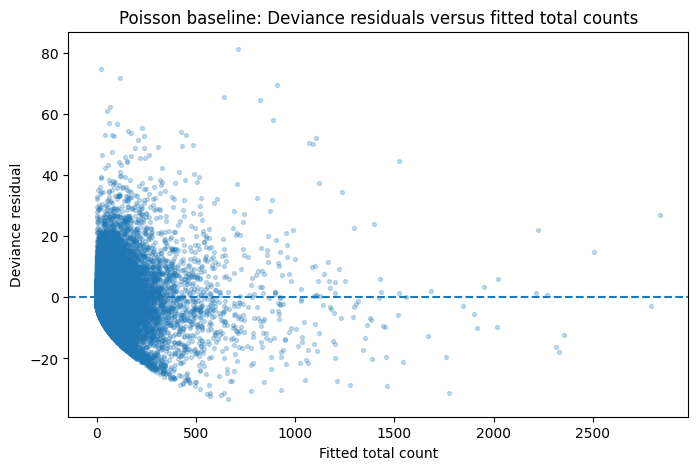

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(
    diagnostic_sample["predicted_total_count"],
    diagnostic_sample["deviance_residual"],
    alpha=0.25,
    s=8
)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted total count")
plt.ylabel("Deviance residual")
plt.title("Poisson baseline: Deviance residuals versus fitted total counts")
plt.show()


Model diagnostics were conducted on the training data. Pearson and deviance dispersion statistics were computed on the aggregated training data, since this is the data used for estimation. In addition, the observed and predicted zero-count shares were compared at the original row level, because zero counts are meaningful for individual 2-hour intervals. Residual plot was produced using a random sample of aggregated training rows.

The diagnostics show that the baseline Poisson model is not adequate for these data. The Pearson dispersion statistic was 52.60 and the deviance dispersion statistic was 40.85, both far above the value of 1 expected under a well-fitting Poisson model. This indicates substantial overdispersion. The model also underpredicted zero counts: the observed row-level zero-count share was 28.26%, while the Poisson-predicted zero-count share was only 8.17%. The residual plot further showed a structured and widely spread residual pattern.

# Negative binomial model

## Negative binomial models

In [24]:
nb_baseline_formula = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
"""

nb_alt1 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(weekday)
"""

nb_alt2 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(direction)
"""


nb_alt3 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(weekday)
    + C(hour_bin):C(direction)
"""


In [25]:
def fit_negative_binomial_model(formula, data, offset, model_name):
    print(f"Fitting {model_name}...")

    model = smf.negativebinomial(
        formula=formula,
        data=data,
        offset=offset
    )

    result = model.fit(
        method="lbfgs",
        maxiter=200,
        disp=True
    )

    print(f"Finished {model_name}")
    print(result.summary())

    return result

In [26]:
nb_baseline = fit_negative_binomial_model(
    formula=nb_baseline_formula,
    data=train_aggregated,
    offset=train_aggregated["log_number_of_periods"],
    model_name="Negative binomial baseline"
)

Fitting Negative binomial baseline...
Finished Negative binomial baseline
                     NegativeBinomial Regression Results                      
Dep. Variable:            total_count   No. Observations:               907596
Model:               NegativeBinomial   Df Residuals:                   907423
Method:                           MLE   Df Model:                          172
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.08634
Time:                        08:01:11   Log-Likelihood:            -3.3960e+06
converged:                       True   LL-Null:                   -3.7169e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.0757      0.034      2.219      0.026       0.009       0.143
C(h

In [27]:
nb_alt1 = fit_negative_binomial_model(
    formula=nb_alt1,
    data=train_aggregated,
    offset=train_aggregated["log_number_of_periods"],
    model_name="Negative binomial with hour × weekday interaction"
)

Fitting Negative binomial with hour × weekday interaction...
Finished Negative binomial with hour × weekday interaction
                     NegativeBinomial Regression Results                      
Dep. Variable:            total_count   No. Observations:               907596
Model:               NegativeBinomial   Df Residuals:                   907357
Method:                           MLE   Df Model:                          238
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.09452
Time:                        08:22:22   Log-Likelihood:            -3.3656e+06
converged:                       True   LL-Null:                   -3.7169e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                   

In [28]:
nb_alt2 = fit_negative_binomial_model(
    formula=nb_alt2,
    data=train_aggregated,
    offset=train_aggregated["log_number_of_periods"],
    model_name="Negative binomial with hour × direction interaction"
)

Fitting Negative binomial with hour × direction interaction...
Finished Negative binomial with hour × direction interaction
                     NegativeBinomial Regression Results                      
Dep. Variable:            total_count   No. Observations:               907596
Model:               NegativeBinomial   Df Residuals:                   907412
Method:                           MLE   Df Model:                          183
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.08636
Time:                        08:32:02   Log-Likelihood:            -3.3959e+06
converged:                       True   LL-Null:                   -3.7169e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                       

In [29]:
nb_alt3 = fit_negative_binomial_model(
    formula=nb_alt3,
    data=train_aggregated,
    offset=train_aggregated["log_number_of_periods"],
    model_name="Negative binomial with both interactions"
)

Fitting Negative binomial with both interactions...
Finished Negative binomial with both interactions
                     NegativeBinomial Regression Results                      
Dep. Variable:            total_count   No. Observations:               907596
Model:               NegativeBinomial   Df Residuals:                   907346
Method:                           MLE   Df Model:                          249
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.09453
Time:                        08:52:20   Log-Likelihood:            -3.3655e+06
converged:                       True   LL-Null:                   -3.7169e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

## Model comparioson

In [ ]:
nb_models = {
    "NB baseline": nb_baseline,
    "NB + hour × weekday": nb_alt1,
    "NB + hour × direction": nb_alt2,
    "NB + both interactions": nb_alt3,
}


,model,log_likelihood,df_model,aic,bic,alpha
0,NB + both interactions,-3.365514e+06,249.0,6.731531e+06,6.734472e+06,1.538889
1,NB + hour × weekday,-3.365567e+06,238.0,6.731614e+06,6.734426e+06,1.538836
2,NB + hour × direction,-3.395898e+06,183.0,6.792166e+06,6.794334e+06,1.650113
3,NB baseline,-3.395961e+06,172.0,6.792270e+06,6.794309e+06,1.650236


In [31]:
def likelihood_ratio_test(reduced_model, full_model):
    lr_stat = 2 * (full_model.llf - reduced_model.llf)
    df_diff = full_model.df_model - reduced_model.df_model
    p_value = stats.chi2.sf(lr_stat, df_diff)

    return {
        "lr_statistic": lr_stat,
        "df_difference": df_diff,
        "p_value": p_value,
    }

In [32]:
lr_tests = []

lr_tests.append({
    "comparison": "NB baseline vs NB + hour × weekday",
    **likelihood_ratio_test(nb_baseline, nb_alt1)
})

lr_tests.append({
    "comparison": "NB baseline vs NB + hour × direction",
    **likelihood_ratio_test(nb_baseline, nb_alt2)
})

lr_tests.append({
    "comparison": "NB + hour × weekday vs NB + both interactions",
    **likelihood_ratio_test(nb_alt1, nb_alt3)
})

lr_tests.append({
    "comparison": "NB + hour × direction vs NB + both interactions",
    **likelihood_ratio_test(nb_alt2, nb_alt3)
})

lr_tests = pd.DataFrame(lr_tests)

lr_tests

,comparison,lr_statistic,df_difference,p_value
0,NB baseline vs NB + hour × weekday,60787.572043,66.0,0.000000e+00
1,NB baseline vs NB + hour × direction,125.793017,11.0,1.233227e-21
2,NB + hour × weekday vs NB + both interactions,105.155657,11.0,1.692557e-17
3,NB + hour × direction vs NB + both interactions,60766.934684,66.0,0.000000e+00


In [33]:
nb_comparison = []

for name, model in nb_models.items():
    nb_comparison.append({
        "model": name,
        "log_likelihood": model.llf,
        "df_model": model.df_model,
        "aic": model.aic,
        "bic": model.bic,
        "alpha": model.params.get("alpha", np.nan),
    })

nb_comparison = pd.DataFrame(nb_comparison)

nb_comparison = nb_comparison.sort_values("aic").reset_index(drop=True)

nb_comparison

,model,log_likelihood,df_model,aic,bic,alpha
0,NB + both interactions,-3.365514e+06,249.0,6.731531e+06,6.734472e+06,1.538889
1,NB + hour × weekday,-3.365567e+06,238.0,6.731614e+06,6.734426e+06,1.538836
2,NB + hour × direction,-3.395898e+06,183.0,6.792166e+06,6.794334e+06,1.650113
3,NB baseline,-3.395961e+06,172.0,6.792270e+06,6.794309e+06,1.650236


### Zero counts diagnostics

In [34]:
predicted_train_nb_alt1 = nb_alt1.predict(
    train_data_model,
    offset=np.zeros(train_data_model.shape[0])
)

predicted_train_nb_alt1 = np.clip(
    predicted_train_nb_alt1,
    1e-9,
    None
)

alpha_nb_alt1 = nb_alt1.params["alpha"]

predicted_zero_probability_train_nb_alt1 = (
    1 + alpha_nb_alt1 * predicted_train_nb_alt1
) ** (-1 / alpha_nb_alt1)

observed_zero_share_train = (
    train_data_model["count_rescaled"] == 0
).mean()

predicted_zero_share_train_nb_alt1 = (
    predicted_zero_probability_train_nb_alt1.mean()
)

print("Observed row-level zero share, train:", observed_zero_share_train)
print("Predicted row-level zero share, NB alternative 1:", predicted_zero_share_train_nb_alt1)
print(
    "Difference observed - predicted:",
    observed_zero_share_train - predicted_zero_share_train_nb_alt1
)
print("Estimated alpha:", alpha_nb_alt1)

Observed row-level zero share, train: 0.28256524457198007
Predicted row-level zero share, NB alternative 1: 0.2501613738637024
Difference observed - predicted: 0.03240387070827766
Estimated alpha: 1.5388363214899472


**Negative binomial model substantially improved the zero-count fit.**

# Gradient Boosting method

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor


In [38]:
tree_features = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
    "fuel_price_petrol_95",
]

tree_target = "count_rescaled"

X_train_tree = train_data_model[tree_features].copy()
y_train_tree = train_data_model[tree_target].copy()

X_validation_tree = validation_data_model[tree_features].copy()
y_validation_tree = validation_data_model[tree_target].copy()

In [39]:
categorical_tree_features = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
]

numeric_tree_features = [
    "fuel_price_petrol_95",
]

In [40]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            categorical_tree_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_tree_features,
        ),
    ],
    remainder="drop"
)

In [41]:
hgb_poisson = HistGradientBoostingRegressor(
    loss="poisson",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=123,
)

In [42]:
hgb_poisson_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", hgb_poisson),
    ]
)

In [43]:
hgb_poisson_pipeline.fit(
    X_train_tree,
    y_train_tree
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

# Compering the Negative Binomial model and Gradient Boosting model

In [44]:

nb_alt1_validation_predicted = nb_alt1.predict(
    validation_data_model,
    offset=np.zeros(validation_data_model.shape[0])
)

nb_alt1_validation_predicted = np.clip(
    nb_alt1_validation_predicted,
    1e-9,
    None
)

nb_alt1_validation_observed = validation_data_model["count_rescaled"]

nb_alt1_validation_results = pd.DataFrame({
    "model": ["Negative binomial: hour × weekday"],
    "validation_mae": [
        mean_absolute_error(
            nb_alt1_validation_observed,
            nb_alt1_validation_predicted
        )
    ],
    "validation_rmse": [
        np.sqrt(
            mean_squared_error(
                nb_alt1_validation_observed,
                nb_alt1_validation_predicted
            )
        )
    ],
    "validation_mean_poisson_deviance": [
        mean_poisson_deviance(
            nb_alt1_validation_observed,
            nb_alt1_validation_predicted
        )
    ],
    "mean_observed_count": [
        nb_alt1_validation_observed.mean()
    ],
    "mean_predicted_count": [
        nb_alt1_validation_predicted.mean()
    ],
})

In [45]:

hgb_validation_predicted = hgb_poisson_pipeline.predict(
    X_validation_tree
)

hgb_validation_predicted = np.clip(
    hgb_validation_predicted,
    1e-9,
    None
)

hgb_validation_observed = y_validation_tree

hgb_validation_results = pd.DataFrame({
    "model": ["Histogram gradient boosting: Poisson loss"],
    "validation_mae": [
        mean_absolute_error(
            hgb_validation_observed,
            hgb_validation_predicted
        )
    ],
    "validation_rmse": [
        np.sqrt(
            mean_squared_error(
                hgb_validation_observed,
                hgb_validation_predicted
            )
        )
    ],
    "validation_mean_poisson_deviance": [
        mean_poisson_deviance(
            hgb_validation_observed,
            hgb_validation_predicted
        )
    ],
    "mean_observed_count": [
        hgb_validation_observed.mean()
    ],
    "mean_predicted_count": [
        hgb_validation_predicted.mean()
    ],
})

In [46]:

validation_model_comparison = pd.concat(
    [
        nb_alt1_validation_results,
        hgb_validation_results,
    ],
    ignore_index=True
)

validation_model_comparison = validation_model_comparison.sort_values(
    "validation_mean_poisson_deviance"
).reset_index(drop=True)

validation_model_comparison

,model,validation_mae,validation_rmse,validation_mean_poisson_deviance,mean_observed_count,mean_predicted_count
0,Histogram gradient boosting: Poisson loss,12.495373,34.004821,14.963154,22.536608,19.119490
1,Negative binomial: hour × weekday,16.509967,39.817522,21.827539,22.536608,22.295862


The histogram gradient boosting model achieved better validation performance in terms of MAE, RMSE and mean Poisson deviance, indicating that nonlinearities and interactions are relevant for prediction.The negative binomial model had weaker individual prediction performance but preserved the average traffic level more closely and provided a more interpretable count-model framework.

### Validation bias check

In [47]:
validation_bias_check = validation_data_model.copy()

validation_bias_check["nb_alt1_predicted"] = nb_alt1_validation_predicted
validation_bias_check["hgb_predicted"] = hgb_validation_predicted

validation_bias_check["nb_alt1_error"] = (
    validation_bias_check["count_rescaled"]
    - validation_bias_check["nb_alt1_predicted"]
)

validation_bias_check["hgb_error"] = (
    validation_bias_check["count_rescaled"]
    - validation_bias_check["hgb_predicted"]
)

bias_by_hour = (
    validation_bias_check
    .groupby("hour_bin")
    .agg(
        observed_mean=("count_rescaled", "mean"),
        nb_predicted_mean=("nb_alt1_predicted", "mean"),
        hgb_predicted_mean=("hgb_predicted", "mean"),
        nb_mean_error=("nb_alt1_error", "mean"),
        hgb_mean_error=("hgb_error", "mean"),
        rows=("count_rescaled", "size"),
    )
    .reset_index()
)

bias_by_hour

,hour_bin,observed_mean,nb_predicted_mean,hgb_predicted_mean,nb_mean_error,hgb_mean_error,rows
0,0,2.712868,2.426060,2.335327,0.286808,0.377541,98958
1,2,1.469062,1.495476,1.621998,-0.026414,-0.152936,98682
2,4,4.320748,5.103812,4.065436,-0.783064,0.255312,98978
3,6,24.130543,27.402963,22.264897,-3.272420,1.865646,99040
4,8,35.692686,34.775520,30.302255,0.917166,5.390431,99042
5,10,29.136059,29.853898,24.964191,-0.717839,4.171868,99038
6,12,35.667649,36.574293,29.463749,-0.906644,6.203901,99040
7,14,41.860831,41.767008,34.178259,0.093824,7.682572,99038
8,16,49.874743,47.770827,41.016607,2.103915,8.858136,99044
9,18,24.964875,22.024869,21.168152,2.940006,3.796723,99046


In [48]:
bias_by_weekday = (
    validation_bias_check
    .groupby("weekday")
    .agg(
        observed_mean=("count_rescaled", "mean"),
        nb_predicted_mean=("nb_alt1_predicted", "mean"),
        hgb_predicted_mean=("hgb_predicted", "mean"),
        nb_mean_error=("nb_alt1_error", "mean"),
        hgb_mean_error=("hgb_error", "mean"),
        rows=("count_rescaled", "size"),
    )
    .reset_index()
)

bias_by_weekday

,weekday,observed_mean,nb_predicted_mean,hgb_predicted_mean,nb_mean_error,hgb_mean_error,rows
0,Friday,23.706237,23.570812,20.454030,0.135425,3.252208,169334
1,Monday,23.753935,22.747856,20.184979,1.006080,3.568957,169240
2,Saturday,17.751556,17.516373,14.569155,0.235183,3.182401,169346
3,Sunday,17.052194,15.319587,13.032407,1.732607,4.019787,169082
4,Thursday,25.250351,24.983173,21.394116,0.267178,3.856236,169326
5,Tuesday,25.247786,26.533479,22.167453,-1.285693,3.080333,169158
6,Wednesday,24.944662,25.337237,21.975651,-0.392575,2.969011,172522


The validation bias checks show that the histogram gradient boosting model has lower overall validation error, but it underpredicts the average number of cyclists across most daytime periods and across all weekdays. The negative binomial model with the hour-by-weekday interaction has higher overall prediction error, but it follows the average hourly and weekday traffic profiles better. For this reason, the negative binomial model is more suitable as the main normal-count model.